<a href="https://colab.research.google.com/github/denverkim/Business-Analytics/blob/main/AILAB1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 고객데이터 분석예제

In [4]:
# 고객파일 열기
import pandas as pd

customer = pd.read_excel('/content/xlmd_customer.xls', header=1)
customer.head()

,CUST ID,REGION,RENT VS. OWN,NUM HOUSEHOLD,ANNUAL INCOME,TOTAL PURCHASES,NUM PURCHASES
0,1,North,Own,1,10K-25K,38,1
1,2,South,Own,4,100K+,30,4
2,3,North,Rent,3,25K-50K,19,3
3,4,West,Own,5,25K-50K,21,6
4,5,East,Own,6,50K-100K,35,7


In [7]:
# Q1. Open Show all information for only customers who live in the North region. 북쪽에 사는 고객들의 정보를 보여주시오
customer[customer.REGION == 'North']

,CUST ID,REGION,RENT VS. OWN,NUM HOUSEHOLD,ANNUAL INCOME,TOTAL PURCHASES,NUM PURCHASES
0,1,North,Own,1,10K-25K,38,1
2,3,North,Rent,3,25K-50K,19,3
8,9,North,Own,5,50K-100K,30,8
10,11,North,Own,1,50K-100K,21,4
16,17,North,Own,6,50K-100K,129,5
...,...,...,...,...,...,...,...
467,468,North,Rent,2,50K-100K,119,3
468,469,North,Own,6,10K-25K,185,6
476,477,North,Own,2,25K-50K,59,4
478,479,North,Rent,5,100K+,60,8


In [14]:
# Q2. Show all information for only customers who (a) live in the North region, (b) own their homes, and (c) have only one household member. 북쪽에 살면서 자기집을 소유하고, 1명의 가정구성원을 가진 고객의 정보를 보여주시오.
customer[(customer.REGION == 'North') & (customer['RENT VS. OWN'] == 'Own') & (customer['NUM HOUSEHOLD'] == 1)]

,CUST ID,REGION,RENT VS. OWN,NUM HOUSEHOLD,ANNUAL INCOME,TOTAL PURCHASES,NUM PURCHASES
0,1,North,Own,1,10K-25K,38,1
10,11,North,Own,1,50K-100K,21,4
347,348,North,Own,1,50K-100K,29,6
483,484,North,Own,1,25K-50K,61,6


In [16]:
# Q3. Show all information for customers who have at least 4 household members. 최소 4명의 가족구성원을 가진 고객들의 정보를 보여주시오.
customer[customer['NUM HOUSEHOLD'] >= 4]

,CUST ID,REGION,RENT VS. OWN,NUM HOUSEHOLD,ANNUAL INCOME,TOTAL PURCHASES,NUM PURCHASES
1,2,South,Own,4,100K+,30,4
3,4,West,Own,5,25K-50K,21,6
4,5,East,Own,6,50K-100K,35,7
7,8,West,Rent,4,25K-50K,25,6
8,9,North,Own,5,50K-100K,30,8
...,...,...,...,...,...,...,...
477,478,East,Own,4,50K-100K,59,7
478,479,North,Rent,5,100K+,60,8
479,480,West,Rent,7,50K-100K,68,9
485,486,East,Own,6,50K-100K,76,9


In [21]:
# Q4. Show all information for customers who (a) have spent less than $20 or (b) more than $100. 20불미만 100불이상 소비한 고객들의 정보를 보여주시오.
customer[(customer['TOTAL PURCHASES'] < 20) | (customer['TOTAL PURCHASES'] > 100)]

,CUST ID,REGION,RENT VS. OWN,NUM HOUSEHOLD,ANNUAL INCOME,TOTAL PURCHASES,NUM PURCHASES
2,3,North,Rent,3,25K-50K,19,3
14,15,South,Rent,3,50K-100K,19,2
15,16,West,Own,5,25K-50K,19,6
16,17,North,Own,6,50K-100K,129,5
19,20,North,Rent,1,50K-100K,119,3
...,...,...,...,...,...,...,...
464,465,East,Own,4,25K-50K,119,7
465,466,South,Rent,5,50K-100K,129,2
467,468,North,Rent,2,50K-100K,119,3
468,469,North,Own,6,10K-25K,185,6


In [22]:
# Q5. Provide a two-dimensional table using crosstab that counts the number of customers by the categories of REGION and RENT VS. OWN. 크로스탭을 이용하여 2차원 테이블을 만들되 지역과 렌트대소유에 따른 고객들의 수를 보여주시오.
pd.crosstab(customer.REGION, customer['RENT VS. OWN'])

RENT VS. OWN,Own,Rent
REGION,,
East,82,66
North,63,62
South,51,47
West,66,50


In [23]:
# Q6. Provide a two-dimensional table using crosstab that sums the TOTAL PURCHASES of customers by the categories of REGION and RENT VS. OWN. 크로스탭을 이용하여 2차원 테이블을 만들되 지역과 렌트대소유에 따른 고객들의 총구매액의 합을 보여주시오.
pd.crosstab(customer.REGION, customer['RENT VS. OWN'], values=customer['TOTAL PURCHASES'], aggfunc='sum')

RENT VS. OWN,Own,Rent
REGION,,
East,5793,4440
North,4260,4502
South,3326,3086
West,4335,3654


In [31]:
# §Q7. Provide a query using Totals that counts the number of customers by the categories of REGION, RENT VS. OWN, and NUM HOUSEHOLD. 토탈스를 이용하여 쿼리를 만들되 지역, 렌트대소유, 가족구성원의 수에 따른 고객들의 수를 보여주시오.
totals = customer.groupby(['REGION', 'RENT VS. OWN', 'NUM HOUSEHOLD']).count()['CUST ID']
totals.rename('고객의 수')

REGION  RENT VS. OWN  NUM HOUSEHOLD
East    Own           1                 6
                      2                 7
                      3                16
                      4                19
                      5                14
                      6                13
                      7                 7
        Rent          1                10
                      2                 8
                      3                14
                      4                12
                      5                10
                      6                 6
                      7                 6
North   Own           1                 4
                      2                12
                      3                11
                      4                10
                      5                13
                      6                10
                      7                 3
        Rent          1                 6
                      2                 9
                      3                19
                      4                 7
                      5                11
                      6                 7
                      7                 3
South   Own           1                 2
                      2                 9
                      3                 8
                      4                17
                      5                 7
                      6                 5
                      7                 3
        Rent          1                 1
                      2                12
                      3                 8
                      4                10
                      5                 7
                      6                 5
                      7                 4
West    Own           1                 5
                      2                 4
                      3                12
                      4                20
                      5                12
                      6                11
                      7                 2
        Rent          1                 3
                      2                 6
                      3                 9
                      4                11
                      5                 9
                      6                 8
                      7                 4
Name: 고객의 수, dtype: int64

In [ ]:
# Q8-Q10. Create three more queries to answer your questions on this database. 추가적으로 3개 쿼리를 더 만드시오.

# 도서관 데이터 분석 실습

In [35]:
book = pd.read_csv('/content/book.txt', encoding="cp949", sep='\t')
book

,book_id,title,author_name,publisher,genre
0,1,무례한 사람에게 웃으며 대처하는 법,정문정,가나출판사,에세이
1,2,신경 끄기의 기술,마크 맨슨/한재호,갤리온,에세이
2,3,82년생 김지영,조남주,민음사,소설
3,4,나의 영어 사춘기,이시원,시원스쿨닷컴,학습서
4,5,언어의 온도,이기주,말글터,에세이
5,6,나는 나로 살기로 했다 (겨울 스페셜 에디션),김수현,마음의숲,에세이
6,7,나미야 잡화점의 기적,히가시노 게이고/양윤옥,현대문학,소설
7,8,말 그릇,김윤나,카시오페아,에세이
8,9,연애의 행방,히가시노 게이고/양윤옥,소미미디어,소설
9,10,마법천자문 41,김창환/홍거북/김성재/올댓스토리,아울북,아동도서


In [38]:
patron = pd.read_csv('/content/patron.txt', encoding="cp949", sep='\t')
patron

,patron_id,patron_name,gender,age,address
0,1,강경두,M,34,"중구 퇴계로 97, 고려대연각타워 601호"
1,2,강락원,M,57,해운대구 센텀 7로 12
2,3,강미선,M,23,성남시 분당구 야탑로 205번길 8
3,4,고영식,M,55,서초구 바우뫼로 27길 2
4,5,공대선,F,44,"종로구 대학로 57 홍익대학교 대학로캠퍼스 교육동 3층, 12층"
5,6,공성엽,F,42,영등포구 경인로 841
6,7,신성호,F,18,광진구 자양로 76
7,8,곽정현,F,47,"광진구 강변역로 2 (구의동, 우체국시설관리단)"
8,9,구민영,M,38,"종로구 종로1길 42, 603호(수송동, 이마빌딩)"
9,10,구성일,M,62,중구 정동길 43


In [40]:
transaction = pd.read_csv('/content/transaction.txt', encoding="cp949", sep='\t')
transaction

,transaction_id,patron_id,book_id,transaction_date,transaction_year,transaction_month
0,1,8,2,3/5/2017,2017,3
1,2,12,18,3/11/2011,2011,3
2,3,2,4,2/13/2013,2013,2
3,4,7,13,8/5/2015,2015,8
4,5,5,20,7/24/2016,2016,7
...,...,...,...,...,...,...
195,196,15,9,4/28/2012,2012,4
196,197,15,8,10/10/2010,2010,10
197,198,12,20,7/26/2016,2016,7
198,199,15,3,12/22/2010,2010,12


In [42]:
book_t = pd.merge(book, transaction, on='book_id')
book_t

,book_id,title,author_name,publisher,genre,transaction_id,patron_id,transaction_date,transaction_year,transaction_month
0,1,무례한 사람에게 웃으며 대처하는 법,정문정,가나출판사,에세이,52,10,8/30/2018,2018,8
1,1,무례한 사람에게 웃으며 대처하는 법,정문정,가나출판사,에세이,70,7,10/6/2014,2014,10
2,1,무례한 사람에게 웃으며 대처하는 법,정문정,가나출판사,에세이,97,9,1/19/2010,2010,1
3,1,무례한 사람에게 웃으며 대처하는 법,정문정,가나출판사,에세이,191,3,2/11/2013,2013,2
4,2,신경 끄기의 기술,마크 맨슨/한재호,갤리온,에세이,1,8,3/5/2017,2017,3
...,...,...,...,...,...,...,...,...,...,...
195,20,해커스 토익 Reading (2018 최신개정판),데이비드 조,해커스어학연구소,학습서,157,14,9/12/2015,2015,9
196,20,해커스 토익 Reading (2018 최신개정판),데이비드 조,해커스어학연구소,학습서,161,8,7/14/2011,2011,7
197,20,해커스 토익 Reading (2018 최신개정판),데이비드 조,해커스어학연구소,학습서,165,5,2/27/2018,2018,2
198,20,해커스 토익 Reading (2018 최신개정판),데이비드 조,해커스어학연구소,학습서,166,10,6/20/2011,2011,6


In [44]:
book_t_p = pd.merge(book_t, patron, on='patron_id')
book_t_p

,book_id,title,author_name,publisher,genre,transaction_id,patron_id,transaction_date,transaction_year,transaction_month,patron_name,gender,age,address
0,1,무례한 사람에게 웃으며 대처하는 법,정문정,가나출판사,에세이,52,10,8/30/2018,2018,8,구성일,M,62,중구 정동길 43
1,1,무례한 사람에게 웃으며 대처하는 법,정문정,가나출판사,에세이,70,7,10/6/2014,2014,10,신성호,F,18,광진구 자양로 76
2,1,무례한 사람에게 웃으며 대처하는 법,정문정,가나출판사,에세이,97,9,1/19/2010,2010,1,구민영,M,38,"종로구 종로1길 42, 603호(수송동, 이마빌딩)"
3,1,무례한 사람에게 웃으며 대처하는 법,정문정,가나출판사,에세이,191,3,2/11/2013,2013,2,강미선,M,23,성남시 분당구 야탑로 205번길 8
4,2,신경 끄기의 기술,마크 맨슨/한재호,갤리온,에세이,1,8,3/5/2017,2017,3,곽정현,F,47,"광진구 강변역로 2 (구의동, 우체국시설관리단)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,20,해커스 토익 Reading (2018 최신개정판),데이비드 조,해커스어학연구소,학습서,157,14,9/12/2015,2015,9,권대경,F,45,"동작구 보라매로 5길 35, 401(신대방동)"
196,20,해커스 토익 Reading (2018 최신개정판),데이비드 조,해커스어학연구소,학습서,161,8,7/14/2011,2011,7,곽정현,F,47,"광진구 강변역로 2 (구의동, 우체국시설관리단)"
197,20,해커스 토익 Reading (2018 최신개정판),데이비드 조,해커스어학연구소,학습서,165,5,2/27/2018,2018,2,공대선,F,44,"종로구 대학로 57 홍익대학교 대학로캠퍼스 교육동 3층, 12층"
198,20,해커스 토익 Reading (2018 최신개정판),데이비드 조,해커스어학연구소,학습서,166,10,6/20/2011,2011,6,구성일,M,62,중구 정동길 43


In [48]:
print(book.shape)
print(patron.shape)
print(transaction.shape)

(20, 5)
(15, 5)
(200, 6)


In [49]:
transaction.columns

Index(['transaction_id', 'patron_id', 'book_id', 'transaction_date',
       'transaction_year', 'transaction_month'],
      dtype='object')

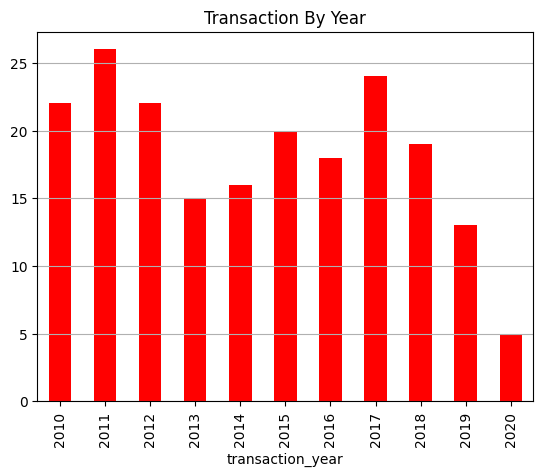

In [60]:
import matplotlib.pyplot as plt

transaction.transaction_year.value_counts().sort_index().plot(kind='bar', color='red')
plt.title('Transaction By Year')
plt.grid(axis='y')
plt.show()